In [2]:
import numpy as np
from sim_library.simulation import simulate_alg_cooling, simulate_alg_cooling_custom, simulate_alg_cooling_custom2
from sim_library.sequences import RR3_gate, RR3short_gate, exchange10_gate, PulseSequence, DownPulse,  gen_MDFEup_seq, FreeEvolution
from sim_library.sequences2 import RR3short_gate as RR3short_gate2
from sim_library.sequences2 import exchange10_gate as exchange10_gate2
from sim_library.data_io import load_p_dists
from sim_library.plotting import plot_coolingcycles_23, plot_coolingcycles_22, plot_coolingcycles_21, fit_gaussian
from sim_library.constants import k_eff, dR, m, omega_eg, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path

In [12]:
# start with uniform distribution

N = 100000

p_dist = np.random.uniform(-16,16, size=N)*hbar*k_eff

cycles = 8

rabi_freq = 2*pi*5e10
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3short_gate(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[16] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

beam_profile = np.full(N, 1)
# beam_profile = np.random.uniform(0.9, 1.1, N)
# beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N)

moms_list, fracs_list = simulate_alg_cooling_custom2(basis=basis, sequence=RR3, time_steps=time_steps, p_dist=p_dist, initial_state=initial_state, beam_profile=beam_profile, cycles=cycles, rabi_freq=rabi_freq, pumping_route='f3',
                                                    #    alternating=True,
                                                        save_dir='data/algorithmic cooling/flat',
                                                        )

MemoryError: Allocation failed (probably too large).

In [ ]:
path = Path("data/algorithmic cooling/2026-04-01_algcooling_f3_16cycles_15muK_10000atoms_5e+05Hz_1.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

In [4]:
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

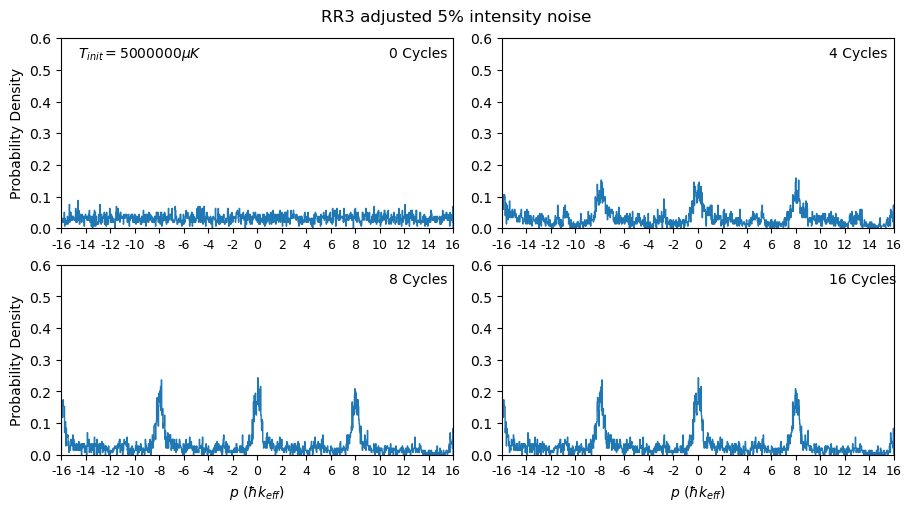

In [6]:
cycles_list = np.array([0,4,8,16])
index_list = np.array([0,8,16,16])
bins_list = np.full(4, 1000)
bins_list[0] = 1000

plot_coolingcycles_22(moms_list=moms_list, fracs_list=fracs_list, basis=basis, cycles_list=cycles_list, index_list=index_list, bins_list=bins_list, title='RR3 adjusted 5% intensity noise', temp=5, show=False,
                      ylims=0.6,
                     #   save_dir="plots/histograms/RR2/2026-03-20_RR2_adjustedMDFE_0.05beam_f3_96cycles_15muK_6000atoms_1e6Hz.png"
                       )

In [ ]:
amp, T, shift, _ = fit_gaussian(moms_list[-1], fracs=fracs_list[-1], lowlim=-2, highlim=2, nbins=2000, plot=True)

print(f'Efficiency: {amp*100:.3g}%')
print(f'Temperature: {T*1e6:.3g}muK')
print(rf'Center: {shift:.3g}hbark')